# Stokes and Mueller Outputs of a Polarized Trace

A polarized trace carries a 3 × 3 polarization ray-tracing (PRT) matrix P
per ray. `optiland.analysis.mueller` turns it into the quantities of
polarimetry: the 2 × 2 Jones matrix and the 4 × 4 Mueller matrix of each
ray path in stated frames, the Stokes vector at a detector, the
diattenuation and the retardance. The Mueller matrix is flux-normalized:
M00 is the transmittance of the path for unpolarized light.

This example checks a quarter-wave retarder, the diattenuation of an
uncoated glass surface over the angle of incidence, and maps the
diattenuation over the pupil of a singlet.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from optiland import optic
from optiland.analysis import mueller
from optiland.coatings import RetarderCoating
from optiland.materials import IdealMaterial
from optiland.rays import PolarizationState, create_polarization

wavelength = 0.633  # µm


def flat(coating=None, field_deg=0.0, state=None, glass=None):
    """One flat surface at the stop; air or ``glass`` behind it."""
    lens = optic.Optic()
    lens.surfaces.add(index=0, radius=np.inf, thickness=np.inf)
    lens.surfaces.add(
        index=1, radius=np.inf, thickness=1.0, is_stop=True, coating=coating
    )
    lens.surfaces.add(index=2)
    lens.set_aperture(aperture_type="EPD", value=2.0)
    lens.fields.set_type(field_type="angle")
    lens.fields.add(y=0.0)
    lens.fields.add(y=max(field_deg, 1.0))
    lens.wavelengths.add(value=wavelength, is_primary=True)
    lens.updater.set_polarization(state or PolarizationState())
    if glass is not None:
        lens.surfaces[1].material_post = glass
        lens.surfaces[1].set_fresnel_coating()
    return lens

## A quarter-wave retarder

`RetarderCoating` with its fast axis along x. The Mueller matrix in the
detector frame (x_det = x projected normal to the ray) is that of a
quarter-wave retarder, the retardance is π/2, and a +45° linear input
leaves left circular (S3 = −1; S3 > 0 is right circular, looking toward the
source).

In [2]:
state = create_polarization("L+45")
qwp = flat(RetarderCoating(np.pi / 2, axis=(1.0, 0.0, 0.0)), state=state)
rays = qwp.trace_generic(Hx=0.0, Hy=0.0, Px=0.0, Py=0.0, wavelength=wavelength)
k = np.array([[0.0, 0.0, 1.0]])
print("Mueller matrix:\n", np.round(mueller.mueller_matrix(rays)[0], 12) + 0.0)
print(
    "retardance / (pi/2):",
    float(mueller.retardance(rays.p, rays.q, k)[0]) / (np.pi / 2),
)

rays = qwp.trace(Hx=0, Hy=0, wavelength=wavelength, num_rays=3, distribution="line_y")
print(
    "Stokes at the detector:\n",
    np.round(mueller.stokes_at_detector(rays, state), 12) + 0.0,
)

Mueller matrix:
 [[ 1.  0.  0.  0.]
 [ 0.  1.  0.  0.]
 [ 0.  0.  0.  1.]
 [ 0.  0. -1.  0.]]
retardance / (pi/2): 1.0
Stokes at the detector:
 [[ 1.  0.  0. -1.]
 [ 1.  0.  0. -1.]
 [ 1.  0.  0. -1.]]


## Diattenuation of a glass surface

An uncoated surface into n = 1.5 transmits s and p differently. The
diattenuation of the path, from the PRT matrix and from the Mueller matrix,
is D = |T_s − T_p| / (T_s + T_p) with the Fresnel amplitudes t_s, t_p, and
M00 is the unpolarized transmittance 1 − (R_s + R_p)/2. The image surface
lies in the glass, so the path has one interface.

max |D(PRT) - closed form|    = 8.4e-14
max |D(Mueller) - closed form| = 6.8e-16
max |M00 - (1 - (Rs + Rp)/2)|  = 1.0e-15


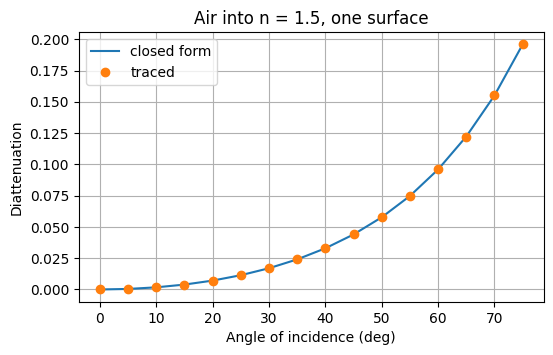

In [3]:
angles = np.arange(0.0, 80.0, 5.0)
d_prt, d_mueller, m00, d_closed, t_closed = [], [], [], [], []
n = 1.5
for angle in angles:
    lens = flat(field_deg=angle, glass=IdealMaterial(n))
    lens.surfaces[2].material_post = IdealMaterial(n)
    hy = 1.0 if angle else 0.0  # the second field of the lens is at ``angle``
    rays = lens.trace_generic(Hx=0.0, Hy=hy, Px=0.0, Py=0.0, wavelength=wavelength)
    theta = np.radians(angle)
    k_in = np.array([[0.0, np.sin(theta), np.cos(theta)]])
    k_out = np.stack([np.ravel(rays.L), np.ravel(rays.M), np.ravel(rays.N)], axis=1)
    M = mueller.mueller_matrix(rays)
    d_prt.append(float(mueller.diattenuation(rays.p, k_in, k_out)[0]))
    d_mueller.append(float(mueller.diattenuation_from_mueller(M)[0]))
    m00.append(float(M[0, 0, 0]))
    c = np.cos(theta)
    root = np.sqrt(n**2 - np.sin(theta) ** 2)
    ts, tp = 2 * c / (c + root), 2 * n * c / (n**2 * c + root)
    rs, rp = (c - root) / (c + root), (n**2 * c - root) / (n**2 * c + root)
    d_closed.append(abs(ts**2 - tp**2) / (ts**2 + tp**2))
    t_closed.append(1 - (rs**2 + rp**2) / 2)

print(
    f"max |D(PRT) - closed form|    = {np.max(np.abs(np.subtract(d_prt, d_closed))):.1e}"
)
print(
    f"max |D(Mueller) - closed form| = {np.max(np.abs(np.subtract(d_mueller, d_closed))):.1e}"
)
print(
    f"max |M00 - (1 - (Rs + Rp)/2)|  = {np.max(np.abs(np.subtract(m00, t_closed))):.1e}"
)

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(angles, d_closed, "-", label="closed form")
ax.plot(angles, d_prt, "o", label="traced")
ax.set_xlabel("Angle of incidence (deg)")
ax.set_ylabel("Diattenuation")
ax.set_title("Air into n = 1.5, one surface")
ax.legend()
ax.grid(True)
plt.show()

## Diattenuation over the pupil of a singlet

A singlet with Fresnel coatings on both surfaces, at a 10° field. Every ray
Mueller matrix is non-depolarizing (depolarization index 1), and M00 equals
the intensity of an unpolarized trace.

depolarization index: min 1.000000000000
max |M00 - rays.i| = 8.9e-16


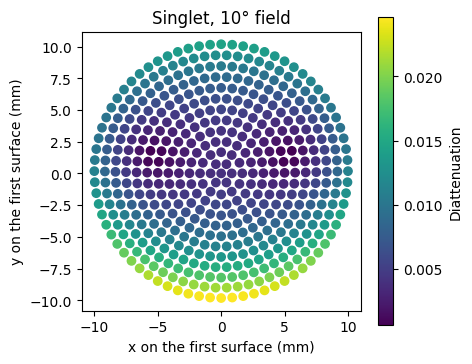

In [4]:
singlet = optic.Optic()
singlet.surfaces.add(index=0, radius=np.inf, thickness=np.inf)
singlet.surfaces.add(
    index=1, radius=50.0, thickness=5.0, material=IdealMaterial(1.6),
    is_stop=True, coating="fresnel",
)  # fmt: skip
singlet.surfaces.add(index=2, radius=-60.0, thickness=90.0, coating="fresnel")
singlet.surfaces.add(index=3)
singlet.set_aperture(aperture_type="EPD", value=20.0)
singlet.fields.set_type(field_type="angle")
singlet.fields.add(y=0.0)
singlet.fields.add(y=10.0)
singlet.wavelengths.add(value=wavelength, is_primary=True)
singlet.updater.set_polarization(PolarizationState(is_polarized=False))

rays = singlet.trace(
    Hx=0, Hy=1, wavelength=wavelength, num_rays=12, distribution="hexapolar"
)
M = mueller.mueller_matrix(rays)
D = np.asarray(mueller.diattenuation_from_mueller(M))
print(f"depolarization index: min {np.min(mueller.depolarization_index(M)):.12f}")
print(f"max |M00 - rays.i| = {np.max(np.abs(M[:, 0, 0] - rays.i)):.1e}")

fig, ax = plt.subplots(figsize=(4.5, 4))
x, y = np.asarray(singlet.surfaces[1].x), np.asarray(singlet.surfaces[1].y)
points = ax.scatter(x, y, c=D, cmap="viridis")
fig.colorbar(points, label="Diattenuation")
ax.set_aspect("equal")
ax.set_xlabel("x on the first surface (mm)")
ax.set_ylabel("y on the first surface (mm)")
ax.set_title("Singlet, 10° field")
plt.show()